In [6]:
import os

if not os.path.exists('/content/SOLENOID_TRACKER'):
    !git clone https://github.com/Egor-Error000/SOLENOID_TRACKER.git
else:
    !git -C /content/SOLENOID_TRACKER pull

!pip install -e /content/SOLENOID_TRACKER -q

# Перезапуск всегда
import IPython
IPython.Application.instance().kernel.do_shutdown(True)


Already up to date.
  Preparing metadata (setup.py) ... done


{'status': 'ok', 'restart': True}

Mounted at /content/drive
Загружено:
  r_grid  : (150,),  [0.0000, 0.0800] м
  z_half  : (150,),  [0.0000, 0.2000] м
  Br_half : (150, 150),  max = 16532.57 мТл
  Bz_half : (150, 150),  max = 45706.47 мТл
FNTFieldGrid создана:
  Nr = 150,  Nz_half = 150
  r  ∈ [0.0000, 0.0800] м
  z  ∈ [0, 0.2000] м  (половинная)
  beta_r  = 6.7902,  alpha_z = 3.1477
  Bz_max  = 45706.47 мТл
  Br_max  = 16532.57 мТл
Тест 1  Br(r=0):   max|Br_axis| / max|Br| = 7.76e-16  ✓
Тест 2  Br(z=0):   max|Br_z0|  / max|Br| = 0.00e+00  ✓
Тест 3  ∇·B=0:     max|∇·B| / max|Bz|    = 9.78e+00  ✗  ОШИБКА
  Есть нарушения — проверьте исходные данные.
ScalingTransform создан:
  γ₀   = 6850.329143
  L0   = 1.000e-01 м
  P0   = 1.871e-18 кг·м/с
  T0   = 3.336e-10 с  (0.3336 нс)
  B0   = 1.168e+02 Тл
Физический шаг   dt  = 10.0000 пс
Безразмерный шаг dt̃  = 2.9979e-02


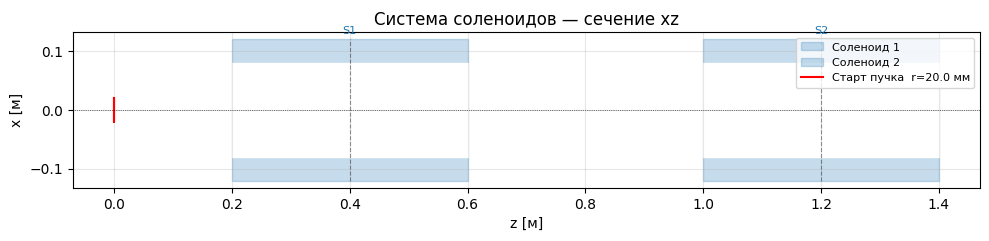

p̃_z (безразм.)   = 1.000000  (должно быть ≈ 1.0)
p_z (физ.)        = 1.8708e-18 кг·м/с
Поперечный импульс ≤ 1.0% от p_z
⟨x₀⟩ = 0.000 мм,  σ_x = 1.000 мм
DimensionlessGridAdapter (FNT):
  r̃ ∈ [0.000, 0.800]
  z̃_half ∈ [0, 2.000]
  B0 = 1.168e+02 Тл
  Соленоиды ẑ_c = [ 4. 12.]
История: 51 кадров  (каждый 20-й шаг из 1000)  ≈ 1224.0 МБ RAM


Трекировка:   0%|          | 0/1000 [00:00<?, ?шаг/s]


── Время выполнения: 146.618 с ──

x_hist : (51, 1000000, 3)  [м]
p_hist : (51, 1000000, 3)  [кг·м/с]
t_hist : (51,)  [с],  t_max = 10.00 нс
Шагов записано  : 1000
γ₀ (теория)     = 6850.329143
⟨γ⟩ финальное   = 6850.557016  (Δγ/γ₀ = 3.33e-05)
⟨|B|⟩ финальное = 0.000 мТл
⟨|F̃|⟩ финальное = 0.000e+00


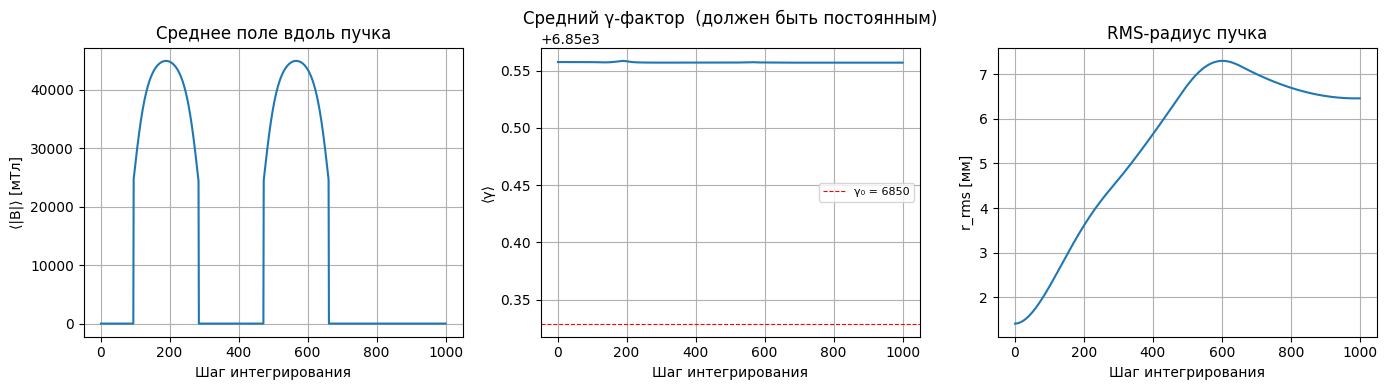

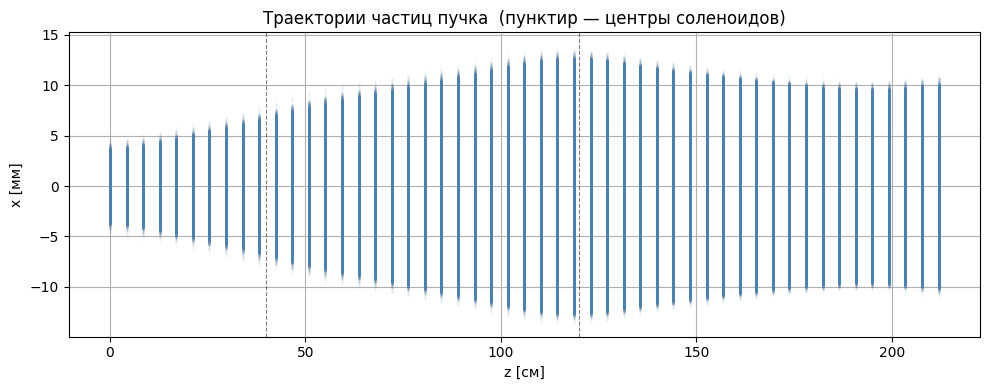

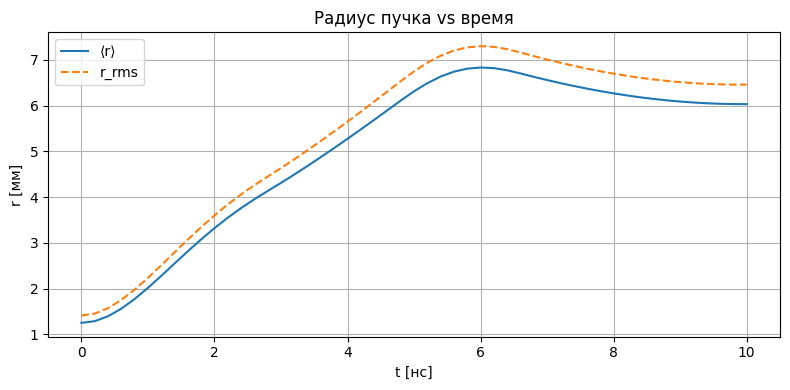

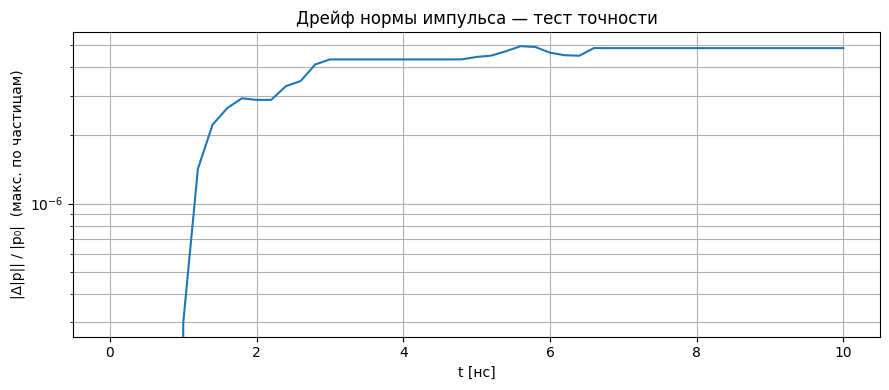

Максимальный дрейф |p| за всё время: 4.96e-06
Финальный дрейф  |p|:                4.86e-06


In [3]:
# experiment.ipynb
import sys
import os


# Добавляем путь к папке solenoid_tracker, чтобы Python видел модули core и physics
# Если вы открыли VS Code прямо в папке solenoid_tracker:

import numpy as np
import matplotlib.pyplot as plt

# ТЕПЕРЬ ИМПОРТЫ РАБОТАЮТ ТАК:
from physics import * # Доступ к c_light, MeV, m_e напрямую
from core import (
    BeamTracerCUDA, 
    FNTFieldGrid, 
    SolenoidParams, 
    BeamPhysicalParams,
    ScalingTransform
)

print(f"✅ Физика загружена: c = {c_light}")
print(f"✅ Ядро загружено: {BeamTracerCUDA}")

# Путь, где теперь лежат ваши папки на сервере Colab
DEST_PATH = "/content/solenoid_tracker" 

if os.path.exists(DEST_PATH):
    if DEST_PATH not in sys.path:
        sys.path.append(DEST_PATH)
    os.chdir(DEST_PATH)
    print(f"✅ Рабочая директория установлена: {os.getcwd()}")
    print("Содержимое:", os.listdir())
else:
    print("❌ Папка всё еще не найдена. Пожалуйста, загрузите её в /content/ через проводник VS Code.")

# Импорт
try:
    from physics import *
    from core import *
    print("🚀 Модули успешно импортированы!")
except Exception as e:
    print(f"Ошибка импорта: {e}")

# Теперь импорты должны сработать
from physics import *
from core import *


import numpy as np
import matplotlib.pyplot as plt

# Импортируем физику напрямую (пишем просто c_light, MeV)
from physics import *

# Импортируем всё необходимое для расчета из ядра
from core import (
    BeamTracerCUDA, 
    FNTFieldGrid, 
    SolenoidParams, 
    BeamPhysicalParams, 
    BeamNumericalParams,
    ScalingTransform,
    plot_solenoid_system
)

# ПРИМЕР ИСПОЛЬЗОВАНИЯ:
# Теперь c_light доступен сразу, так как он пришел из physics/__init__.py
print(f"Скорость света: {c_light}")



# ============================================================
# БЛОК VI — Загрузка данных, инициализация и запуск
# ============================================================


# ── Ячейка 0: монтирование Drive и загрузка FNT-файла ────────────────────────

from google.colab import drive
drive.mount('/content/drive')

ALPHA_FNT = 3.1477
BETA_FNT  = 6.7902

FNT_PATH = '/content/drive/MyDrive/КУРСОВАЯ РАБОТА/FNT_half_grid_data(150x150_Z+).npy'

fnt_data                   = np.load(FNT_PATH, allow_pickle=True)
spf_grid, Br_half, Bz_half = fnt_data[0]
r_grid_fnt, z_half_fnt     = spf_grid

r_grid_fnt = r_grid_fnt * 1e-2
z_half_fnt = z_half_fnt * 1e-2

print(f"Загружено:")
print(f"  r_grid  : {r_grid_fnt.shape},  [{r_grid_fnt[0]:.4f}, {r_grid_fnt[-1]:.4f}] м")
print(f"  z_half  : {z_half_fnt.shape},  [{z_half_fnt[0]:.4f}, {z_half_fnt[-1]:.4f}] м")
print(f"  Br_half : {Br_half.shape},  max = {np.max(np.abs(Br_half))*1e3:.2f} мТл")
print(f"  Bz_half : {Bz_half.shape},  max = {np.max(np.abs(Bz_half))*1e3:.2f} мТл")


# ── Ячейка 1: FNTFieldGrid + валидация ───────────────────────────────────────

fnt_grid = FNTFieldGrid(
    r_grid  = r_grid_fnt,
    z_half  = z_half_fnt,
    Br_half = Br_half,
    Bz_half = Bz_half,
    beta_r  = BETA_FNT,
    alpha_z = ALPHA_FNT,
)

fnt_grid.check_symmetry()
# fnt_grid.plot()


# ── Ячейка 2: физические параметры ───────────────────────────────────────────

beam_phys = BeamPhysicalParams(
    mass           = m_e,
    charge         = -e_charge,
    c              = c_light,
    kinetic_energy = 3.5e9 * eV,
)

scaling = ScalingTransform.from_physical_problem(
    phys = beam_phys,
    L0   = 0.1,
)

# T0 выводится в from_physical_problem — используем его для выбора t_end.
# При T0 ≈ 0.334 нс и t_end=15 нс получаем ~44.9 безразмерных единиц времени.
# dt̃ = (t_end - t_start) / (n_steps · T0) вычисляется автоматически в run().

beam_num = BeamNumericalParams(
    t_start           = 0.0,      # [с]
    t_end             = 10e-9,    # [с]  ≈ 45 · T0
    n_steps           = 1000,
    threads_per_block = 128,      # было 256 → 20 блоков; теперь 128 → 40 блоков
)

# Информация о шаге
dt_phys   = (beam_num.t_end - beam_num.t_start) / beam_num.n_steps
dt_dimless = dt_phys / scaling.T0
print(f"Физический шаг   dt  = {dt_phys*1e12:.4f} пс")
print(f"Безразмерный шаг dt̃  = {dt_dimless:.4e}")

z1 = 0.40
z2 = 1.20
solenoids = [
    SolenoidParams(center=np.array([0.0, 0.0, z1]),
                   const=1.0, length=2*b, R_inner=R-a, R_outer=R+a),
    SolenoidParams(center=np.array([0.0, 0.0, z2]),
                   const=1.0, length=2*b, R_inner=R-a, R_outer=R+a),
]

plot_solenoid_system(solenoids, z_start=0.0, r_beam=2e-2)


# ── Ячейка 3: начальные условия ──────────────────────────────────────────────

N_PARTICLES = 1_000_000
STRIDE      = 20

rng = np.random.default_rng(seed=42)

x0 = np.zeros((N_PARTICLES, 3), dtype=np.float32)
x0[:, 0] = rng.normal(0.0, 1e-3, N_PARTICLES)
x0[:, 1] = rng.normal(0.0, 1e-3, N_PARTICLES)

# energy_to_momentum возвращает p̃ = p/P0 (безразм.) —
# умножаем на P0 чтобы получить физический импульс [кг·м/с] для run()
p_z_dimless = scaling.energy_to_momentum(beam_phys.kinetic_energy)
p_z_phys    = p_z_dimless * scaling.P0

p0 = np.zeros((N_PARTICLES, 3), dtype=np.float32)
p0[:, 2] = p_z_phys

frac = 0.01
p0[:, 0] = p_z_phys * rng.uniform(-frac, frac, N_PARTICLES)
p0[:, 1] = p_z_phys * rng.uniform(-frac, frac, N_PARTICLES)

print(f"p̃_z (безразм.)   = {p_z_dimless:.6f}  (должно быть ≈ 1.0)")
print(f"p_z (физ.)        = {p_z_phys:.4e} кг·м/с")
print(f"Поперечный импульс ≤ {frac*100:.1f}% от p_z")
print(f"⟨x₀⟩ = {x0[:,0].mean()*1e3:.3f} мм,  σ_x = {x0[:,0].std()*1e3:.3f} мм")


# ── Ячейка 4: адаптер + трекировщик + запуск ─────────────────────────────────

adapted = DimensionlessGridAdapter(fnt_grid, scaling, solenoids=solenoids)

diagnostics = BeamDiagnostics()

tracer = BeamTracerCUDA(
    adapted_grid = adapted,
    phys         = beam_phys,
    num          = beam_num,
    scaling      = scaling,
    diagnostics  = diagnostics,
)

x_hist, p_hist, t_hist = tracer.run(
    x0, p0,
    store_history = True,
    stride        = STRIDE,
)

print(f"\nx_hist : {x_hist.shape}  [м]")
print(f"p_hist : {p_hist.shape}  [кг·м/с]")
print(f"t_hist : {t_hist.shape}  [с],  t_max = {t_hist[-1]*1e9:.2f} нс")


# ── Ячейка 5: диагностика пучка ──────────────────────────────────────────────

gamma0_ref = 1.0 + beam_phys.kinetic_energy / (m_e * c_light**2)

print(f"Шагов записано  : {len(diagnostics.steps)}")
print(f"γ₀ (теория)     = {gamma0_ref:.6f}")
print(f"⟨γ⟩ финальное   = {diagnostics.mean_gamma[-1]:.6f}  "
      f"(Δγ/γ₀ = {abs(diagnostics.mean_gamma[-1] - gamma0_ref)/gamma0_ref:.2e})")
print(f"⟨|B|⟩ финальное = {diagnostics.mean_B[-1]*1e3:.3f} мТл")
print(f"⟨|F̃|⟩ финальное = {diagnostics.mean_F[-1]:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(diagnostics.steps, np.array(diagnostics.mean_B) * 1e3)
axes[0].set_xlabel("Шаг интегрирования")
axes[0].set_ylabel("⟨|B|⟩ [мТл]")
axes[0].set_title("Среднее поле вдоль пучка")
axes[0].grid(True)

axes[1].plot(diagnostics.steps, diagnostics.mean_gamma)
axes[1].axhline(gamma0_ref, color='r', linestyle='--',
                linewidth=0.8, label=f'γ₀ = {gamma0_ref:.0f}')
axes[1].set_xlabel("Шаг интегрирования")
axes[1].set_ylabel("⟨γ⟩")
axes[1].set_title("Средний γ-фактор  (должен быть постоянным)")
axes[1].legend(fontsize=8)
axes[1].grid(True)

axes[2].plot(diagnostics.steps, np.array(diagnostics.rms_r) * 1e3)
axes[2].set_xlabel("Шаг интегрирования")
axes[2].set_ylabel("r_rms [мм]")
axes[2].set_title("RMS-радиус пучка")
axes[2].grid(True)

plt.tight_layout()
plt.show()


# ── Ячейка 6: траектории в плоскости (z, x) ──────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    x_hist[:, :, 2].reshape(-1) * 1e2,
    x_hist[:, :, 0].reshape(-1) * 1e3,
    '.', alpha=0.03, markersize=1, color='steelblue',
)
for sol in solenoids:
    ax.axvline(sol.center[2] * 1e2, color='k', linestyle='--',
               linewidth=0.8, alpha=0.5)
ax.set_xlabel("z [см]")
ax.set_ylabel("x [мм]")
ax.set_title("Траектории частиц пучка  (пунктир — центры соленоидов)")
ax.grid(True)
plt.tight_layout()
plt.show()


# ── Ячейка 7: средний и RMS-радиус пучка vs время ────────────────────────────

r_hist      = np.sqrt(x_hist[:, :, 0]**2 + x_hist[:, :, 1]**2)
r_mean_hist = r_hist.mean(axis=1)
r_rms_hist  = np.sqrt(np.mean(r_hist**2, axis=1))
t_ns        = t_hist * 1e9

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_ns, r_mean_hist * 1e3, label='⟨r⟩')
ax.plot(t_ns, r_rms_hist  * 1e3, label='r_rms', linestyle='--')
ax.set_xlabel("t [нс]")
ax.set_ylabel("r [мм]")
ax.set_title("Радиус пучка vs время")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# ── Ячейка 8: тест точности — дрейф нормы импульса ───────────────────────────

p_norm     = np.linalg.norm(p_hist, axis=2)
p_norm_rel = p_norm / p_norm[0, :]
drift      = np.abs(p_norm_rel - 1.0).max(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_ns, drift)
ax.set_xlabel("t [нс]")
ax.set_ylabel("|Δ|p|| / |p₀|  (макс. по частицам)")
ax.set_title("Дрейф нормы импульса — тест точности")
ax.grid(True, which='both')
plt.tight_layout()
plt.show()

print(f"Максимальный дрейф |p| за всё время: {drift.max():.2e}")
print(f"Финальный дрейф  |p|:                {drift[-1]:.2e}")